### Objetivo

##### Utilizar técnicas de clasificación aprendidas hasta el momento para predecir la calidad del vino basándose en características físico-químicas. Este ejercicio permitirá aplicar conceptos como la selección de características, preprocesamiento de datos, entrenamiento y evaluación de modelos de clasificación, y análisis de resultados mediante métricas y visualizaciones.

##### Descripción del Dataset: Este conjunto de datos contiene información sobre distintas características físico-químicas de muestras de vino tinto y su calidad asociada. Las características incluyen acidez fija, acidez volátil, ácido cítrico, azúcar residual, cloruros, dióxido de azufre libre, dióxido de azufre total, densidad, pH, sulfatos y alcohol. La calidad del vino está clasificada en una escala del 0 al 10.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV , cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier,GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, classification_report,ConfusionMatrixDisplay, f1_score, precision_score, recall_score ,roc_auc_score , roc_curve , confusion_matrix




#### 1. Carga y Exploración de Datos:



- 1.1 Cargar el dataset y revisar su estructura básica.


In [18]:
# 1.1 Cargar el dataset
df = pd.read_csv('data/WineQT.csv')

print("\ndimensiones")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("\nprimeras 5 filas\n")
display(df.head(10))

# los ultimos 5 registros
display("\nultimos 5 registros : \n",df.tail())


print("\n nombres de las columnas \n")
display(df.columns.tolist())

print("\ntipos de datos \n")
print(df.info())

print("\n estadisticas descriptivas \n")
display(df.describe())

# Crear target binario
df['quality_bin'] = (df['quality'] >= 7).astype(int)
df = df.drop(columns=['quality'])



dimensiones
Filas: 1143, Columnas: 13


primeras 5 filas



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


'\nultimos 5 registros : \n'

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597



 nombres de las columnas 



['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality',
 'Id']


tipos de datos 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None

 estadisticas descriptivas 



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


- 1.2 Describir las variables y su distribución.


|	Columna	|	Tipo	|	Descripcion	|
|	 ---------------------	|	 ------------	|	 -----------------------	|
|'	fixed acidity	 '|	float64	|	Acidez fija	|
|'	volatile acidity	 '|	float64	|	Acidez volatil	|
|'	citric acid	 '|	float64	|	Acido citrico	|
|'	residual sugar	 '|	float64	|	Azucar residual	|
|'	chlorides	 '|	float64	|	Cloruros	|
|'	free sulfur dioxide	 '|	float64	|	Dioxido de azufre libre	|
|'	total sulfur dioxide	 '|	float64	|	Dioxido de azufre total	|
|'	density	 '|	float64	|	Densidad	|
|'	pH	 '|	float64	|	pH	|
|'	sulphates	 '|	float64	|	Sulfatos	|
|'	alcohol	 '|	float64	|	Grado alcoholico	|
|'	quality	 '|	int64	|	Variable objetivo (3-8)	|
|'	Id	 '|	int64	|	Identificador	|


<!-- |	Columna	|	Tipo	|	Descripcion	|
|	 ---------------------	|	 ------------	|	 -----------------------	|
|'	fixed acidity	 '|	float64	|	Acidez fija	|
|'	volatile acidity	 '|	float64	|	Acidez volatil	|
|'	citric acid	 '|	float64	|	Acido citrico	|
|'	residual sugar	 '|	float64	|	Azucar residual	|
|'	chlorides	 '|	float64	|	Cloruros	|
|'	free sulfur dioxide	 '|	float64	|	Dioxido de azufre libre	|
|'	total sulfur dioxide	 '|	float64	|	Dioxido de azufre total	|
|'	density	 '|	float64	|	Densidad	|
|'	pH	 '|	float64	|	pH	|
|'	sulphates	 '|	float64	|	Sulfatos	|
|'	alcohol	 '|	float64	|	Grado alcoholico	|
|'	quality	 '|	int64	|	Variable objetivo (3-8)	|
|'	Id	 '|	int64	|	Identificador	| -->


- 1.3 Identificar y tratar valores nulos y outliers.

In [19]:
# verificar datos nulos en el dataframe
print("\nDatos nulos por columna : \n")
print(df.isnull().sum())
print("\nDatos nulos totales : ", df.isnull().sum().sum())

print("\nNo se encuentran valores nulos en el dataset, por lo que no es necesario realizar imputación de datos.")



Datos nulos por columna : 

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
quality_bin             0
dtype: int64

Datos nulos totales :  0

No se encuentran valores nulos en el dataset, por lo que no es necesario realizar imputación de datos.


In [20]:
# deteccion de outliarns en el dataframe
print("\n deteccion de outliarns en el dataframe.\n")
# columnas numericas
colum_numericas = [col for col in df if df[col].dtype in ['int64', 'float64']]

print("\n columnas numericas : ", colum_numericas)

# columnas categoricas
colum_categoricas = [col for col in df if df[col].dtype == 'object']

print("\n columnas categoricas :  ", colum_categoricas, "\n")

def deteccion_outliers(df_e, column):
    Q1 = df_e[column].quantile(0.25)
    Q3 = df_e[column].quantile(0.75)
    IQR = Q3 - Q1
    limit_inf = Q1 - 1.5 * IQR
    limit_sup = Q3 + 1.5 * IQR
    outliers = df_e[(df_e[column] < limit_inf) | (df_e[column] > limit_sup)]
    return outliers, limit_inf, limit_sup

def remover_outliers(df_e, column):
    Q1 = df_e[column].quantile(0.25)
    Q3 = df_e[column].quantile(0.75)
    IQR = Q3 - Q1
    limit_inf = Q1 - 1.5 * IQR
    limit_sup = Q3 + 1.5 * IQR
    df_out = df_e[(df_e[column] >= limit_inf) & (df_e[column] <= limit_sup)]
    return df_out

def mostrar_correccion_outliers(df_lim, column, arr_outliers):
   # print("arr_outliers", arr_outliers[column])

    existe = any(arr== column for arr in arr_outliers)
    #print("existe : ", existe)
    if existe: 
        outliers = df_lim[(df_lim[column] < arr_outliers[column]['lower']) | (df_lim[column] > arr_outliers[column]['upper'])]
 #       print(f"outliers {df_lim[column]} " )
 #       display("mostrar outliers", outliers)
        count = len(outliers) # cuenta la cantidad de outliers encontrados en la columna
        print(f"{column:18} -> cantidad de outliers = {count:3} | limites : [{arr_outliers[column]['lower']:,.2f}, {arr_outliers[column]['upper']:,.2f}]")

arr_outliers = {}

for col in colum_numericas:
        outliers, lower, upper = deteccion_outliers(df, col)
        # Guardas los valores

        count = len(outliers) # cuenta la cantidad de outliers encontrados en la columna
        if count > 0:
            print(f"{col:18} -> cantidad de outliers = {count:3} | limites : [{lower:,.2f}, {upper:,.2f}]")
            nombre_outlier = col
            arr_outliers.update({nombre_outlier: {'upper': upper, 'lower': lower}})


 deteccion de outliarns en el dataframe.


 columnas numericas :  ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id', 'quality_bin']

 columnas categoricas :   [] 

fixed acidity      -> cantidad de outliers =  44 | limites : [4.10, 12.10]
volatile acidity   -> cantidad de outliers =  14 | limites : [0.02, 1.01]
citric acid        -> cantidad de outliers =   1 | limites : [-0.40, 0.91]
residual sugar     -> cantidad de outliers = 110 | limites : [0.85, 3.65]
chlorides          -> cantidad de outliers =  77 | limites : [0.04, 0.12]
free sulfur dioxide -> cantidad de outliers =  18 | limites : [-14.00, 42.00]
total sulfur dioxide -> cantidad de outliers =  40 | limites : [-39.00, 121.00]
density            -> cantidad de outliers =  36 | limites : [0.99, 1.00]
pH                 -> cantidad de outliers =  20 | limites : [2.91, 3.69]
sulphates          -> cantidad

In [21]:
print("\nCorrección de outliers")

df_clean = df.copy()

for col in colum_numericas:            
    df_clean = remover_outliers(df_clean, col)



print("\n mostrar corrección de outlierns. \n ")
#display('df_limpio',df_limpio['length'])
#display(arr_outliers)
for col in colum_numericas:
    #print(f"columna : {col} ")
    mostrar_correccion_outliers(df_clean, col, arr_outliers)




Corrección de outliers

 mostrar corrección de outlierns. 
 
fixed acidity      -> cantidad de outliers =   0 | limites : [4.10, 12.10]
volatile acidity   -> cantidad de outliers =   0 | limites : [0.02, 1.01]
citric acid        -> cantidad de outliers =   0 | limites : [-0.40, 0.91]
residual sugar     -> cantidad de outliers =   0 | limites : [0.85, 3.65]
chlorides          -> cantidad de outliers =   0 | limites : [0.04, 0.12]
free sulfur dioxide -> cantidad de outliers =   0 | limites : [-14.00, 42.00]
total sulfur dioxide -> cantidad de outliers =   0 | limites : [-39.00, 121.00]
density            -> cantidad de outliers =   0 | limites : [0.99, 1.00]
pH                 -> cantidad de outliers =   0 | limites : [2.91, 3.69]
sulphates          -> cantidad de outliers =   0 | limites : [0.28, 1.00]
alcohol            -> cantidad de outliers =   0 | limites : [7.10, 13.50]
quality_bin        -> cantidad de outliers =   0 | limites : [0.00, 0.00]


### 2. Preprocesamiento de Datos:



##### - 2.1 Seleccionar características importantes para la clasificación.


In [22]:

columnas = ['fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol',
    'quality_bin']

# Eliminar filas con nulos para correlación
df_clean = df.dropna(subset=columnas)

# Matriz de correlación
correlacion = df_clean[columnas].corr()

# Correlación con price
print('\ncolumnas con correlacion a columna quality: \n',correlacion['quality_bin'].sort_values(ascending=False).round(4))

# Filtrar características altamente correlacionadas con la variable objetivo mayor a 0.5
objetivo_corr = abs(correlacion['quality_bin'])
columnas_relevantes = objetivo_corr[objetivo_corr > 0.5]
print('\n columnas importantes con correlacion mayor a 0.5 : \n ',columnas_relevantes.index)


columnas con correlacion a columna quality: 
 quality_bin             1.0000
alcohol                 0.4037
citric acid             0.2511
sulphates               0.2080
fixed acidity           0.1232
residual sugar          0.0641
free sulfur dioxide    -0.0560
pH                     -0.0733
chlorides              -0.1040
total sulfur dioxide   -0.1134
density                -0.1487
volatile acidity       -0.3045
Name: quality_bin, dtype: float64

 columnas importantes con correlacion mayor a 0.5 : 
  Index(['quality_bin'], dtype='object')


##### - 2.2 Transformar variables categóricas en variables numéricas si es necesario.


In [23]:
# Verificar si hay variables categóricas
print("\n=== Tipos de datos ===")
print(df_clean.dtypes)

# en esta ocacion no se encuentran variables categoricas para tranformarlas a numericas, por lo que no es necesario realizar codificación de variables categóricas.

df2 = df_clean.copy()


=== Tipos de datos ===
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
Id                        int64
quality_bin               int64
dtype: object


##### - 2.3 Dividir los datos en conjuntos de entrenamiento y prueba.


In [24]:
# Features y target
X = df2.drop(columns=['quality_bin'])
y = df2['quality_bin']

# División train/test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### - 2.4 Escalar las características.

In [25]:
# Escalado de características
scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc  = scaler.transform(X_test)

### 3. Entrenamiento de Modelos de Clasificación:



##### - 3.1 Entrenar al menos tres modelos de clasificación diferentes (por ejemplo, KNN, RandomForest, y Regresión Logística).


MSE: 0 
R²: -0.0218 (-2.2%)


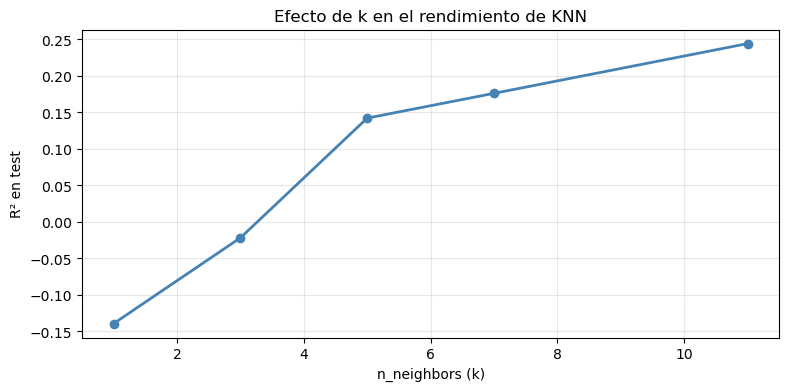

👉 Mejor k: 11 con R² = 0.2444
   Notar cómo k=1 suele ser peor (ruidoso) y k muy grande también baja (subajuste).


In [26]:
# Entrenamiento del modelo KNN
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train_esc, y_train)

# Realizar predicciones
y_pred = knn.predict(X_test_esc)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:,.0f} ')
print(f'R²: {r2:.4f} ({r2*100:.1f}%)')

# ¿Cómo cambia el R² con distintos k?
ks = [1, 3, 5, 7, 11]
scores = []

for k in ks:
    m = KNeighborsRegressor(n_neighbors=k).fit(X_train_esc, y_train)
    scores.append(m.score(X_test_esc, y_test))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, scores, marker='o', linewidth=2, color='steelblue')
ax.set_xlabel('n_neighbors (k)')
ax.set_ylabel('R² en test')
ax.set_title('Efecto de k en el rendimiento de KNN')
ax.grid(alpha=0.3)
plt.show()

mejor_k = ks[np.argmax(scores)]
print(f'👉 Mejor k: {mejor_k} con R² = {max(scores):.4f}')
print('   Notar cómo k=1 suele ser peor (ruidoso) y k muy grande también baja (subajuste).')

R²:   0.1590 (15.9%)
MSE  : 0.11


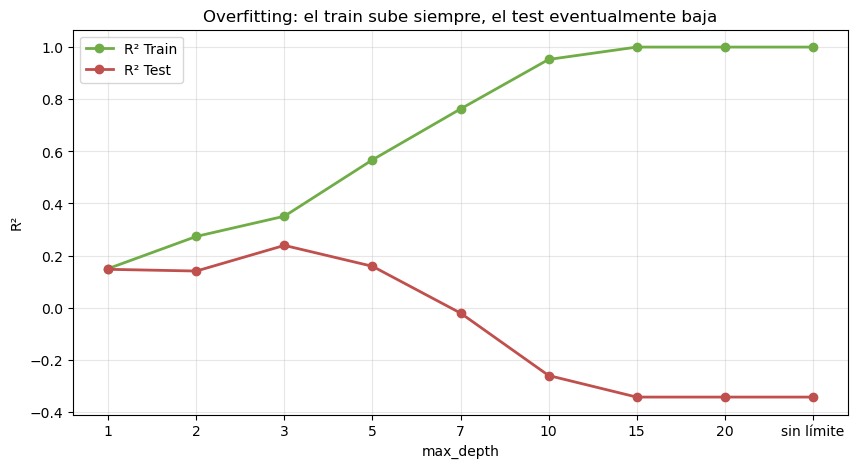

👉 Mira cómo el R² de train llega a casi 1.0 con árboles muy profundos.
   Pero el R² de test EMPIEZA A BAJAR — eso es overfitting.
   El truco está en encontrar el max_depth óptimo (típicamente 4-7).


In [27]:
modelo_arbol = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_arbol.fit(X_train, y_train)

y_pred = modelo_arbol.predict(X_test)

print(f'R²:   {r2_score(y_test, y_pred):.4f} ({r2_score(y_test, y_pred)*100:.1f}%)')
print(f"MSE  : {mse:,.2f}")

#  El overfitting de los árboles — ver cómo cambia el R² según max_depth
depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
scores_train, scores_test = [], []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_train_esc, y_train)
    scores_train.append(m.score(X_train_esc, y_train))
    scores_test.append(m.score(X_test_esc, y_test))

fig, ax = plt.subplots(figsize=(10, 5))
x_labels = [str(d) if d is not None else 'sin límite' for d in depths]
ax.plot(x_labels, scores_train, marker='o', linewidth=2, color='#70AD47', label='R² Train')
ax.plot(x_labels, scores_test, marker='o', linewidth=2, color='#C0504D', label='R² Test')
ax.set_xlabel('max_depth')
ax.set_ylabel('R²')
ax.set_title('Overfitting: el train sube siempre, el test eventualmente baja')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print('👉 Mira cómo el R² de train llega a casi 1.0 con árboles muy profundos.')
print('   Pero el R² de test EMPIEZA A BAJAR — eso es overfitting.')
print('   El truco está en encontrar el max_depth óptimo (típicamente 4-7).')

In [28]:
#Limpieza de ceros como nulos
#for c in ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol','quality', 'Id']:
for c in ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']:
    df2[c] = df2[c].replace(0, np.nan)
df2 = df2.fillna(df2.median(numeric_only=True))

#display(df2)
X = df2.drop(columns=['quality_bin'])
y = df2['quality_bin']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Regresión logística con estandarización (CRÍTICO para interpretar coeficientes)
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, 
                          zero_division=0,     # ← SOLUCIÓN PRINCIPAL
                          digits=4))

Accuracy: 0.8659
              precision    recall  f1-score   support

           0     0.9003    0.9492    0.9241       295
           1     0.5312    0.3542    0.4250        48

    accuracy                         0.8659       343
   macro avg     0.7158    0.6517    0.6745       343
weighted avg     0.8487    0.8659    0.8542       343



##### - 3.2 Utilizar validación cruzada para seleccionar los mejores hiperparámetros.

In [29]:
#  KNN, RandomForest, y Regresión Logística

print(f'{'Regrecion Lineal':20s} -> R²={r2_score(y_test, y_pred):.4f} ({r2_score(y_test, y_pred)*100:.1f}%), MAE=${mean_absolute_error(y_test, y_pred):.0f}')

modelos = {
    'KNN':     make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10)),
    'RF':      RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42)),
}

scores = {}
for nombre, m in modelos.items():
    m.fit(X_train, y_train); scores[nombre] = r2_score(y_test, m.predict(X_test))
tabla = pd.Series(scores).sort_values(ascending=False)
print('Benchmark:'); print(tabla.round(4))

# Tuning del ganador 
grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [10, 15, None]},
    cv=3, scoring='r2', n_jobs=-1
).fit(X_train, y_train)
print(f'\nMejor RF tuned: {grid.best_params_}')
print(f'R² sin tuning: {tabla["RF"]:.4f}')
print(f'R² con tuning: {grid.score(X_test, y_test):.4f}')


Regrecion Lineal     -> R²=-0.1143 (-11.4%), MAE=$0
Benchmark:
RF                     0.2642
KNN                    0.0832
Logistic Regression   -0.1143
dtype: float64

Mejor RF tuned: {'max_depth': 10, 'n_estimators': 200}
R² sin tuning: 0.2642
R² con tuning: 0.2723


### 4. Evaluación de Modelos:



- 4.1 Evaluar los modelos utilizando métricas como exactitud, precisión, recall, F1-Score y matriz de confusión.


           Accuracy  Precision  Recall      F1
Modelo                                        
KNN(k=11)    0.8455     0.8306  0.8455  0.8369
RF(200)      0.8921     0.8847  0.8921  0.8874
LogReg       0.8659     0.8487  0.8659  0.8542


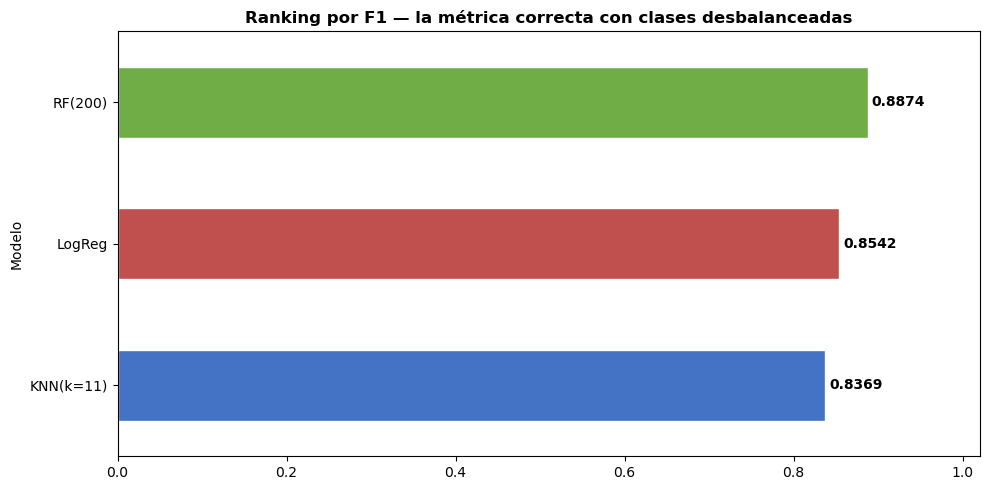


GANADOR según F1: RF(200) con F1 = 0.8874


In [30]:



modelos = {
    'KNN(k=11)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=11)),
    'RF(200)':   make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    'LogReg':    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,random_state=42))
}

filas = []
for nombre, m in modelos.items():
    m.fit(X_train, y_train)
    pred  = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    filas.append({
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, pred, average='weighted', zero_division=0),
        'F1':        f1_score(y_test, pred, average='weighted', zero_division=0)
    })
tabla = pd.DataFrame(filas).set_index('Modelo').round(4)
print(tabla)

# Barplot del F1 (la métrica clave)
fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#4472C4', '#C0504D', '#70AD47', '#ED7D31']
tabla['F1'].sort_values().plot(kind='barh', color=colores, edgecolor='white', ax=ax)
for i, v in enumerate(tabla['F1'].sort_values()):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')
ax.set_title('Ranking por F1 — la métrica correcta con clases desbalanceadas', fontweight='bold')
ax.set_xlim(0, max(tabla['F1']) * 1.15)
plt.tight_layout(); plt.show()

ganador = tabla['F1'].idxmax()
print(f'\nGANADOR según F1: {ganador} con F1 = {tabla.loc[ganador, "F1"]:.4f}')

Accuracy:    0.8659
Precision:   0.8487
Recall:      0.8659
F1:          0.8542

Classification report:
0    311
1     32
Name: quality_bin, dtype: int64
              precision    recall  f1-score   support

           0     0.9003    0.9492    0.9241       295
           1     0.5312    0.3542    0.4250        48

    accuracy                         0.8659       343
   macro avg     0.7158    0.6517    0.6745       343
weighted avg     0.8487    0.8659    0.8542       343



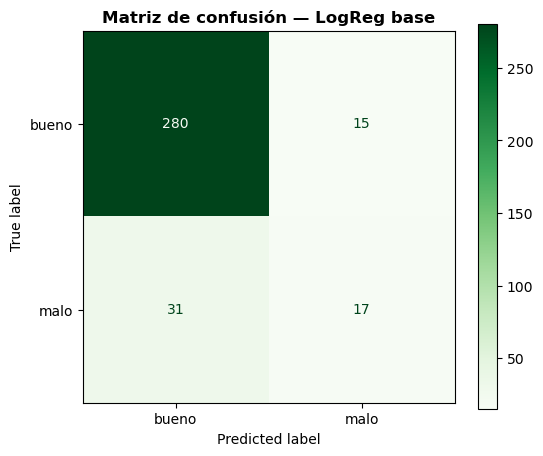

In [ ]:
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(f'Accuracy:    {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision:   {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}')
print(f'Recall:      {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}')
print(f'F1:          {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}')
print(f'\nClassification report:')
print(y_test.groupby(y_pred).size())  # Ver distribución de clases predichas
print(classification_report(y_test, y_pred, zero_division=0,  digits=4))


#cabeceras = np.sort(y_test.unique()).astype(str)
cabeceras = ['bueno','malo']
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Greens', display_labels=cabeceras, xticks_rotation='horizontal')
ax.set_title('Matriz de confusión — LogReg base', fontweight='bold')
plt.show()




- 4.2 Generar un informe de clasificación para cada modelo.



- 4.2.1. Random Forest (n_estimators=200)
    - **Desempeño General:** Excelente
    - **El modelo Random Forest con 200 árboles es el que mejor rendimiento obtuvo en esta tarea de clasificación.**
    - **Accuracy: 89.21% ; Precision: 88.47% ; Recall: 89.21% ; F1-Score: 88.74%** 
    - **Conclusión: Random Forest destaca como el modelo más robusto y equilibrado. Su capacidad para manejar el desbalanceo de clases y capturar patro**

- 4.2.2. Logistic Regression
    - **Desempeño General:** Bueno
    - **La Regresión Logistica obtuvo un rendimiento muy bueno, ubicandose en segundo lugar.**
    - **Accuracy: 86.59 ; Precision: 84.87% ; Recall: 86.59% ; F1-Score: 85.42%** 
    - **Conclusión: Logro un buen equilibrio en las metricas cercano a RF es una excelente opcion para buscar interpretacion y entrenamiento**

- 4.2.3. KNN (k=11)
    - **Desempeño General:** Aceptable
    - **El modelo KNN fue el que menor rendimiento obtuvo.**
    - **Accuracy: 84.55% ; Precision: 88.87% ; Recall: 86.59% ; F1-Score: 85.42%** 
    - **Conclusión: el modelo KNN muestra un comportamiento consistente su F1 mas bajo nos dice que tiene problema en equilibrar presicion y recall**        


- 4.3 Crear y visualizar la curva ROC y calcular el AUC para el mejor modelo.

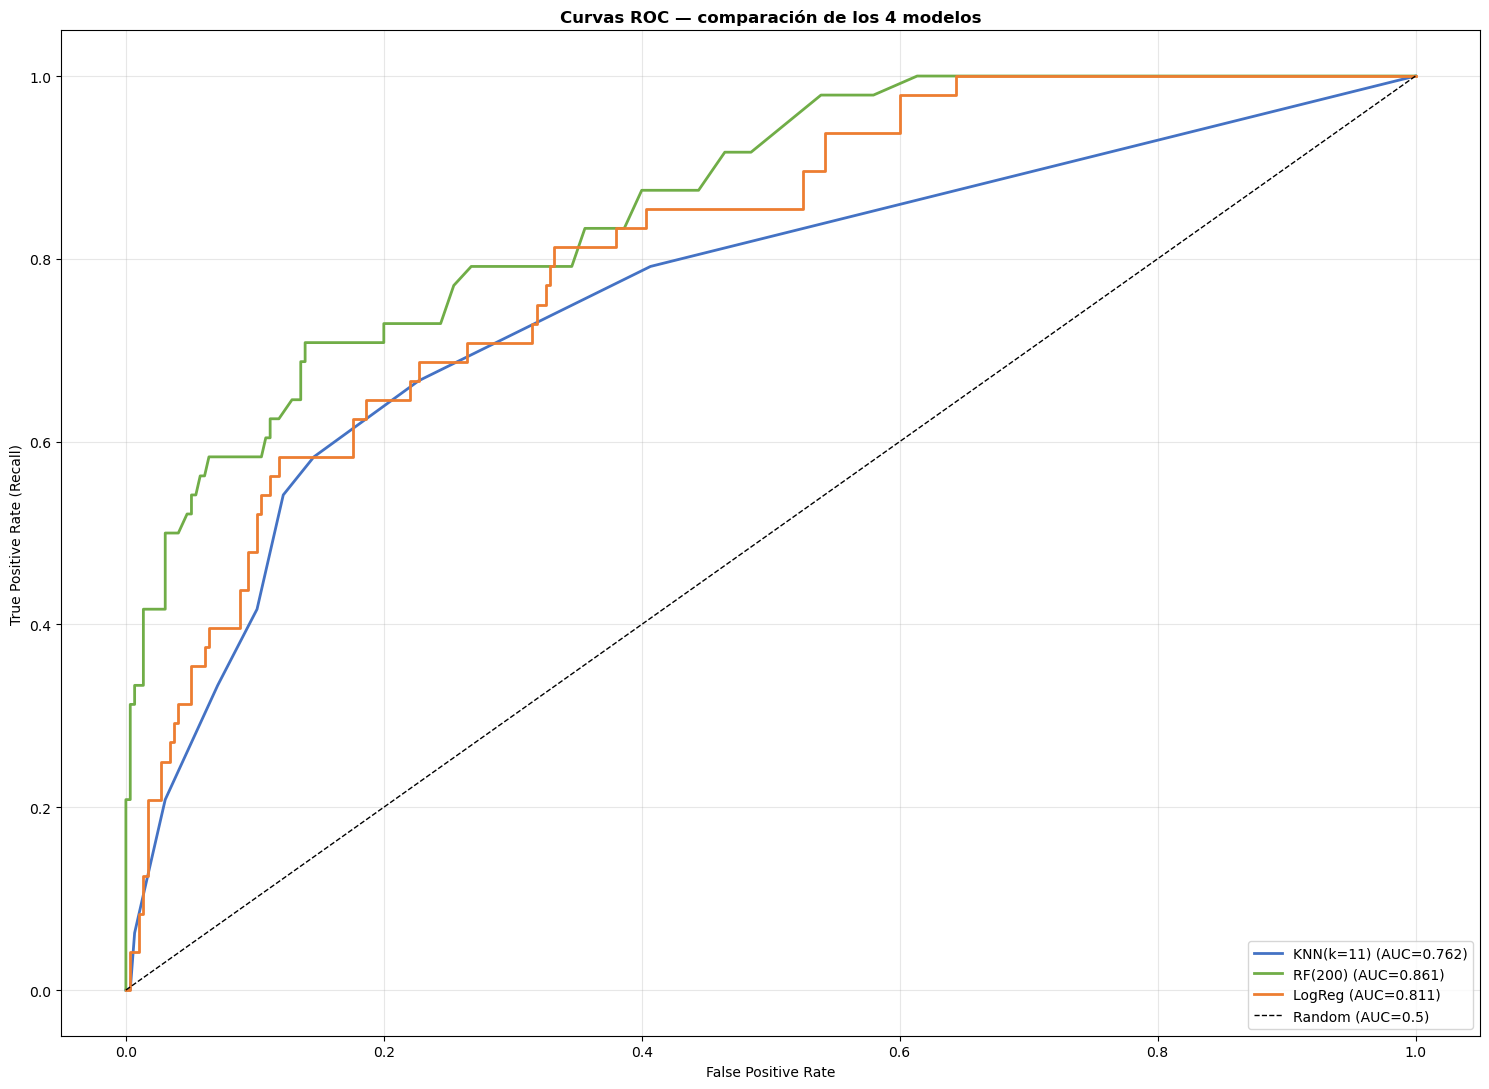

In [64]:
fig, axes = plt.subplots( figsize=(15, 11))

# Curvas ROC de los 4 modelos en el mismo gráfico

colores_roc = {'KNN(k=11)':'#4472C4', 'DT(d=5)':'#C0504D', 'RF(200)':'#70AD47', 'LogReg':'#ED7D31'}
for nombre, m in modelos.items():
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes.plot(fpr, tpr, color=colores_roc[nombre], linewidth=2,
                 label=f'{nombre} (AUC={auc:.3f})')
axes.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.5)')
axes.set_xlabel('False Positive Rate')
axes.set_ylabel('True Positive Rate (Recall)')
axes.set_title('Curvas ROC — comparación de los 4 modelos', fontweight='bold')
axes.legend(loc='lower right')
axes.grid(alpha=0.3)


plt.tight_layout(); plt.show()

In [72]:
modelos = {
    'KNN(k=11)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=11)),
    'RF(200)':   make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    'LogReg':    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,random_state=42))
}

filas = []
for nombre, m in modelos.items():
    m.fit(X_train, y_train)
    pred  = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    filas.append({
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, pred, average='weighted', zero_division=0),
        'F1':        f1_score(y_test, pred, average='weighted', zero_division=0),
        'AUC':       roc_auc_score(y_test, proba)})

tabla = pd.DataFrame(filas).set_index('Modelo').round(4)
print(tabla)    

           Accuracy  Precision  Recall      F1     AUC
Modelo                                                
KNN(k=11)    0.8455     0.8306  0.8455  0.8369  0.7621
RF(200)      0.8921     0.8847  0.8921  0.8874  0.8614
LogReg       0.8659     0.8487  0.8659  0.8542  0.8114
